# Challenge 5 — Hierarchical Clustering

## Public Health & Epidemiology

This notebook implements Hierarchical Agglomerative Clustering on the BRFSS dataset.

Unlike K-Means and DBSCAN, hierarchical clustering constructs a nested hierarchy of observations by iteratively merging the closest clusters.

This approach is useful for:
- identifying hierarchical relationships,
- exploring gradual population transitions,
- and analyzing cluster structures at multiple resolutions.

The analysis includes:
- dendrogram visualization,
- linkage method comparison,
- clustering evaluation metrics,
- and PCA-based visualizations.

In [1]:
# =========================================================
# HIERARCHICAL CLUSTERING
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from scipy.cluster.hierarchy import (
    dendrogram,
    linkage
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Data Loading

Hierarchical clustering has high computational complexity, particularly for large datasets.

To improve scalability while preserving the global structure of the epidemiological feature space:
- PCA-reduced data is used,
- and a representative random subsample is selected.

In [2]:
# =========================
# Load PCA dataset
# =========================

X_pca = np.load("../results/X_pca.npy")

print("PCA shape:", X_pca.shape)

PCA shape: (29999, 20)


In [3]:
# =========================
# Subsample for Hierarchical Clustering
# =========================

SAMPLE_SIZE = 5000

indices = np.random.choice(
    X_pca.shape[0],
    SAMPLE_SIZE,
    replace=False
)

X_hierarchical = X_pca[indices]

print("Hierarchical sample shape:", X_hierarchical.shape)

Hierarchical sample shape: (5000, 20)


# Dendrogram Analysis

A dendrogram visually represents the hierarchical merging process.

Large vertical jumps indicate merges between relatively distant clusters and may suggest meaningful cluster boundaries.

Due to computational constraints, the dendrogram is generated using a reduced subset of observations.

In [4]:
# =========================
# Dendrogram subset
# =========================

DENDRO_SIZE = 1000

dendro_indices = np.random.choice(
    X_hierarchical.shape[0],
    DENDRO_SIZE,
    replace=False
)

X_dendro = X_hierarchical[dendro_indices]

print("Dendrogram subset shape:", X_dendro.shape)

Dendrogram subset shape: (1000, 20)


In [5]:
# =========================
# Linkage matrix
# =========================

linkage_matrix = linkage(
    X_dendro,
    method='ward'
)

print("Linkage matrix computed.")

Linkage matrix computed.


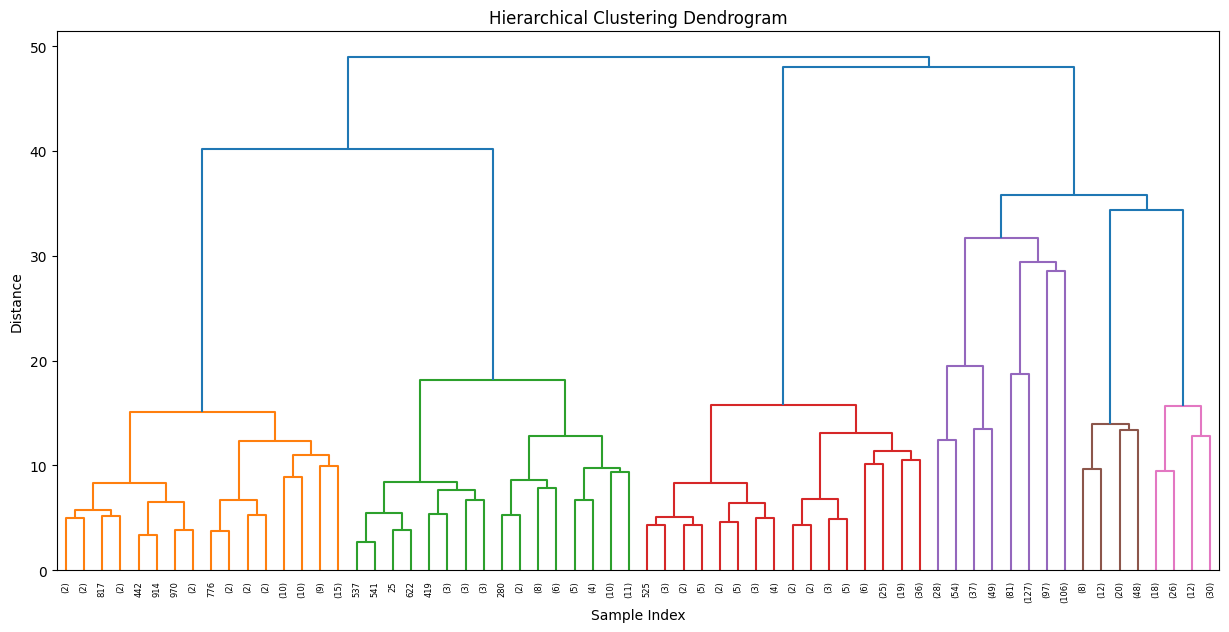

In [6]:
# =========================
# Dendrogram
# =========================

plt.figure(figsize=(15, 7))

dendrogram(
    linkage_matrix,
    truncate_mode='level',
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.savefig("../figures/dendrogram.png")
plt.show()

# Final Hierarchical Clustering Configuration

Based on the dendrogram analysis, the final Agglomerative Clustering configuration was selected with:

- `n_clusters = 4`
- `linkage = ward`

This configuration captures meaningful hierarchical separation while maintaining cluster interpretability and avoiding excessive fragmentation.

In [7]:
# =========================
# Final Hierarchical Model
# =========================

N_CLUSTERS = 4

hierarchical = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    linkage='ward'
)

hierarchical_labels = hierarchical.fit_predict(
    X_hierarchical
)

print("Hierarchical clustering completed.")

Hierarchical clustering completed.


In [8]:
# =========================
# Cluster distribution
# =========================

cluster_distribution = (
    pd.Series(hierarchical_labels)
    .value_counts()
    .sort_index()
)

print(cluster_distribution)

0    3780
1     333
2     550
3     337
Name: count, dtype: int64


In [9]:
# =========================
# Evaluation Metrics
# =========================

silhouette = silhouette_score(
    X_hierarchical,
    hierarchical_labels
)

davies_bouldin = davies_bouldin_score(
    X_hierarchical,
    hierarchical_labels
)

calinski_harabasz = calinski_harabasz_score(
    X_hierarchical,
    hierarchical_labels
)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz:.4f}")

Silhouette Score: 0.1691
Davies-Bouldin Index: 1.7875
Calinski-Harabasz Index: 465.5214


# PCA Visualization of Hierarchical Clusters

The PCA projection provides a visual representation of the hierarchical cluster structure identified by Agglomerative Clustering.

Compared to centroid-based approaches, hierarchical clustering captures gradual relationships between observations and may reveal nested population structures.

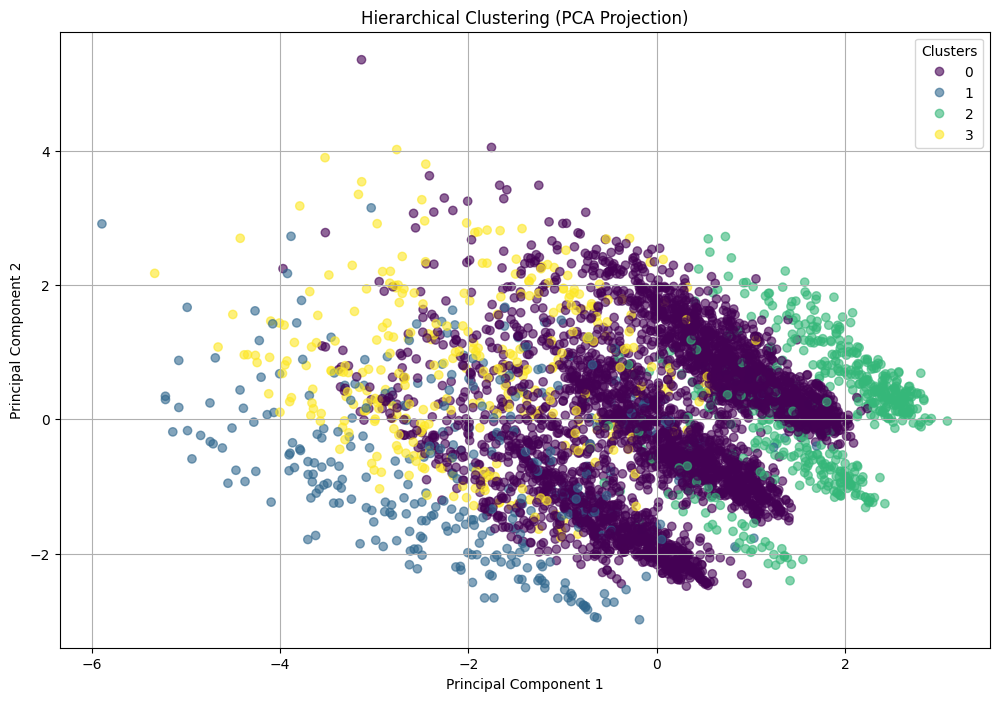

In [10]:
# =========================
# PCA Visualization
# =========================

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    X_hierarchical[:, 0],
    X_hierarchical[:, 1],
    c=hierarchical_labels,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Hierarchical Clustering (PCA Projection)")

plt.legend(
    *scatter.legend_elements(),
    title="Clusters"
)

plt.grid(True)
plt.savefig("../figures/hierarchical_pca.png")
plt.show()